
=== Subject 1 ===
Started Jul 14 2025 12:40:00
Seed is 42
1 Training Set EEG torch.Size([1680, 1, 30, 4000]) fNIRS torch.Size([1680, 1, 72, 200]) Labels torch.Size([1680])
1 Testing Set EEG torch.Size([60, 1, 30, 4000]) fNIRS torch.Size([60, 1, 72, 200]) Labels torch.Size([60])
Subject 1 | Epoch 1/1 | LR 0.001
Train Loss: 0.96 | Train Acc: 0.57 | Eval Loss: 0.84 | Eval Acc: 0.80
Logging Completed
Ended Jul 14 2025 12:40:19 Duration 18.34397840499878 s


2025-07-14 12:40:20.648 | INFO     | Notification:send_yagmail:24 - Email Sent!


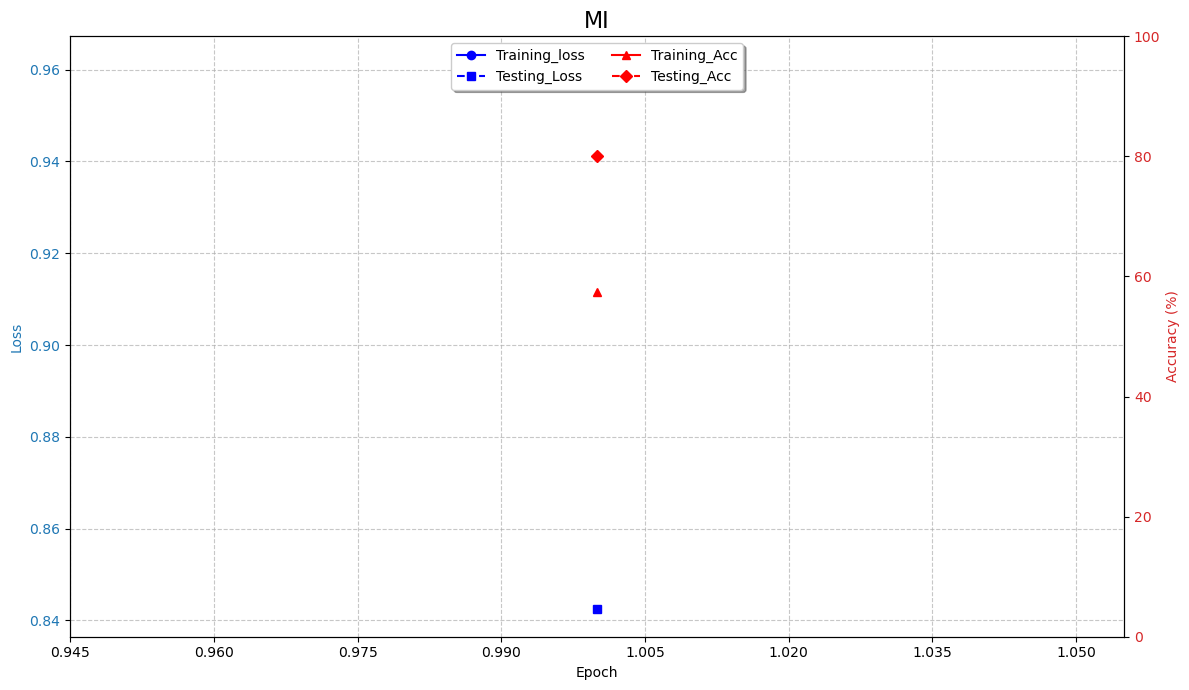

In [ ]:
from EF_Book_VQ import EF_Book as ef
from EF_Book_SharedVQ import EF_Book as ef_sharedvq
from EF_Book_PrivateVQ import EF_Book as ef_privatevq
from EF_Book_NoVQ import EF_Book as ef_novq
from EF_Book_EEG import EF_Book as ef_eeg
from EF_Book_NIRS import EF_Book as ef_nirs
from Dataloader_EF import read_ef_train_si as si_data
from Metrics import metrics, save_param
from Visualization import Visualization as vis
from Notification import send_yagmail

import numpy as np
import torch
from torch import nn
from sklearn.metrics import precision_score, recall_score, f1_score, cohen_kappa_score
import os
import time


class Trainer:
	def __init__(self, config):
		self.config = config
		self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

		if config['model_id'] == 1:
			self.model = ef_sharedvq(config['dict_len'], config['emb_size'], config['num_class'], config['threshold'], self.device).to(self.device).to(torch.float64)
		elif config['model_id'] == 2:
			self.model = ef_privatevq(config['dict_len'], config['emb_size'], config['num_class'], config['threshold'], self.device).to(self.device).to(torch.float64)
		elif config['model_id'] == 3:
			self.model = ef_novq(config['dict_len'], config['emb_size'], config['num_class'], config['threshold'], self.device).to(self.device).to(torch.float64)
		elif config['model_id'] == 4:
			self.model = ef_eeg(config['dict_len'], config['emb_size'], config['num_class'], config['threshold'], self.device).to(self.device).to(torch.float64)
		elif config['model_id'] == 5:
			self.model = ef_nirs(config['dict_len'], config['emb_size'], config['num_class'], config['threshold'], self.device).to(self.device).to(torch.float64)
		
		self.criterion = nn.CrossEntropyLoss()
		self.optimizer = torch.optim.Adam(self.model.parameters(), lr=config['learning_rate'], weight_decay=config['learning_rate'])
		self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
			self.optimizer,
			mode='min',
			factor=0.8,
			patience=5,
			min_lr=0.1*config['learning_rate'],
		)

		self.results_root = 'Results/' + config['exp_name']
		os.makedirs(self.results_root, exist_ok=True)
	
	def z_score_mm(self, train_dataset, test_dataset, eps=1e-6):
		train_eeg = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
		train_eeg_mean = train_eeg.mean(dim=(0,1), keepdim=True)
		train_eeg_std = train_eeg.std(dim=(0,1),keepdim=True)
		train_eeg = (train_eeg - train_eeg_mean) / (train_eeg_std + eps)

		train_nirs = torch.stack([train_dataset[i][1] for i in range(len(train_dataset))])
		train_nirs_mean = train_nirs.mean(dim=(0,1), keepdim=True)
		train_nirs_std = train_nirs.std(dim=(0,1),keepdim=True)
		train_nirs = (train_nirs - train_nirs_mean) / (train_nirs_std + eps)

		train_labels = torch.stack([train_dataset[i][2] for i in range(len(train_dataset))])
		train_dataset = torch.utils.data.TensorDataset(train_eeg, train_nirs, train_labels)

		eval_eeg = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
		eval_eeg = (eval_eeg - train_eeg_mean) / (train_eeg_std + eps)
		eval_nirs = torch.stack([test_dataset[i][1] for i in range(len(test_dataset))])
		eval_nirs = (eval_nirs - train_nirs_mean) / (train_nirs_std + eps)
		eval_labels = torch.stack([test_dataset[i][2] for i in range(len(test_dataset))])
		test_dataset = torch.utils.data.TensorDataset(eval_eeg, eval_nirs, eval_labels)

		return train_dataset, test_dataset
	
	def train_subject(self, subject, mode):
		train_dataset, eval_dataset = si_data(subject, mode)
		if self.config['z_score']:
			train_dataset, eval_dataset = self.z_score_mm(train_dataset, eval_dataset)
		train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=self.config['batch_size'], shuffle=True)
		eval_loader = torch.utils.data.DataLoader(eval_dataset, batch_size=self.config['batch_size'], shuffle=False)
	
		best_acc = 0
		train_loss_list, train_acc_list = [], []
		loss_list, acc_list, precision_list, recall_list, f1_list, kappa_list = [], [], [], [], [], []
		for epoch in range(self.config['num_epochs']):
			#----------Training----------
			self.model.train()
			total_correct, total_loss = 0, 0

			num_batch = len(train_loader)
			for i, (batch_eeg, batch_nirs, batch_labels) in enumerate(train_loader):
				batch_eeg = batch_eeg.to(self.device, dtype=torch.float64)
				batch_nirs = batch_nirs.to(self.device, dtype=torch.float64)
				batch_labels = batch_labels.to(self.device)
				last_batch = (i == num_batch - 1)
				
				model_output = self.model(batch_eeg, batch_nirs, last_batch=last_batch)
				outputs = model_output['outputs']
				quan_loss = model_output['quan_loss']
				cls_loss = self.criterion(outputs, batch_labels.long())
				loss = cls_loss + self.config['quan_lambda'] * quan_loss
				self.optimizer.zero_grad()
				loss.backward()
				self.optimizer.step()
				
				preds = torch.argmax(outputs, dim=1)
				total_correct += (preds == batch_labels).sum().item()
				total_loss += loss.item()

			train_loss = total_loss / len(train_loader)
			train_acc = total_correct / len(train_loader.dataset)
			train_loss_list.append(train_loss)
			train_acc_list.append(train_acc)

			#----------Evaluation----------
			self.model.eval()
			total_loss, total_correct = 0, 0
			all_preds, all_labels = [], []
			
			with torch.no_grad():
				for eval_eeg, eval_nirs, eval_labels in eval_loader:
					eval_eeg = eval_eeg.to(self.device, dtype=torch.float64)
					eval_nirs = eval_nirs.to(self.device, dtype=torch.float64)
					eval_labels = eval_labels.to(self.device)
					
					model_output = self.model(eval_eeg, eval_nirs, last_batch=False)
					outputs = model_output['outputs']
					quan_loss = model_output['quan_loss']
					cls_loss = self.criterion(outputs, eval_labels.long())
					loss = cls_loss + self.config['quan_lambda'] * quan_loss
					total_loss += loss.item()
					
					preds = torch.argmax(outputs, dim=1)
					total_correct += (preds == eval_labels).sum().item()
					
					all_preds.extend(preds.cpu().numpy())
					all_labels.extend(eval_labels.cpu().numpy())
			
			eval_loss = total_loss / len(eval_loader)
			self.scheduler.step(loss)
			eval_acc = total_correct / len(eval_loader.dataset)
			if eval_acc > best_acc:
				best_acc = eval_acc
				torch.save(self.model.state_dict(), self.results_root + f'{subject}.pt')
			precision = precision_score(all_labels, all_preds, zero_division=0)
			recall = recall_score(all_labels, all_preds, zero_division=0)
			f1 = f1_score(all_labels, all_preds, zero_division=0)
			kappa = cohen_kappa_score(all_labels, all_preds)

			loss_list.append(eval_loss)
			acc_list.append(eval_acc)
			precision_list.append(precision)
			recall_list.append(recall)
			f1_list.append(f1)
			kappa_list.append(kappa)
			
			print(f"Subject {subject} | Epoch {epoch+1}/{self.config['num_epochs']} | LR {self.optimizer.param_groups[0]['lr']}")
			print(f"Train Loss: {train_loss:.2f} | Train Acc: {train_acc:.2f} | Eval Loss: {eval_loss:.2f} | Eval Acc: {eval_acc:.2f}")

		train_acc_list = [acc * 100 for acc in train_acc_list]
		acc_list = [acc * 100 for acc in acc_list]
		precision_list = [precision * 100 for precision in precision_list]
		recall_list = [recall * 100 for recall in recall_list]
		f1_list = [f1 * 100 for f1 in f1_list]

		# self.vis = vis(subject, mode, self.results_root)
		# self.vis.plot_all(train_loss_list, train_acc_list, loss_list, acc_list, all_labels, all_preds)

		data = {
			'Train_Loss': train_loss_list,
			'Train_Acc': train_acc_list,
			'Loss': loss_list,
			'Acc': acc_list,
			'Precision': precision_list,
			'Recall': recall_list,
			'F1': f1_list,
			'Kappa': kappa_list,
		}
		log_root = self.results_root + f'{str(subject)}.xlsx'
		metrics(log_root, data)
		return all_labels, all_preds

# Hyperparameters
config = {
	'num_class': 2,
	'mi_root': '../../Dataset/EF-MI-MA/MI/',
	'ma_root': '../../Dataset/EF-MI-MA/MA/',
	'wg_root' : '../../Dataset/EF-WG/WG/',
	'dict_len': 2048,
	'emb_size': 64,
	'threshold': 60,
	'batch_size': 32,
	'num_epochs': 100,
	'learning_rate': 1e-3,
	'quan_lambda': 0.1,
	'mode': 0,
	'model_id': 0,
	'exp_name': '8016/',
	'z_score': True,
}

# Instantiate trainer
mode = config['mode']
num_subject = 5
results_root = 'Results/' + config['exp_name']
seeds, total_labels, total_preds = [], [], []
for subject in range(1, num_subject+1):
	seed = 42
	# seed = random.randint(1, 2025)
	seeds.append(seed)
	torch.manual_seed(seed)
	torch.cuda.manual_seed_all(seed)
	start_time = time.time()
	start_time_string = time.strftime('%b %d %Y %H:%M:%S', time.localtime(start_time))
	print(f"\n=== Subject {subject} ===")
	print(f'Started {start_time_string}')
	print(f'Seed is {seed}')
	trainer = Trainer(config)
	all_labels, all_preds = trainer.train_subject(subject, mode)
	total_labels.append(all_labels)
	total_preds.append(all_preds)
	end_time = time.time()
	end_time_string = time.strftime('%b %d %Y %H:%M:%S', time.localtime(end_time))
	print(f'Ended {end_time_string} Duration {end_time-start_time} s')

# Save parameters
save_param(results_root, config, seeds)
total_labels = np.array(total_labels).reshape(-1)
total_preds = np.array(total_preds).reshape(-1)
cm_visual = vis(subject, mode, results_root)
cm_visual.plot_cm_all(total_labels, total_preds)
send_yagmail(config['exp_name'].split('/')[-2])